<a href="https://colab.research.google.com/github/lorek/Probability_Course_Labs/blob/main/LAB_LIST_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Paweł Lorek  
University of Wrocław

<font face="Rage" size=2  > Updated: 05.03.2026 <font>


# Laboratorium z rachunku prawdopodobieństwa
# Lista 2


# Rozgrzewka: najczęstszy wynik rzutu kostką
Rzucamy sześcienną kostką. Spodziewamy się, że każdy wynik rzutu będzie się pojawiał jednakowo często.
Jednak w rzeczywistości taka sytuacja praktycznie się nie zdarza.

* *Pytanie 1*: Jaka jest szansa, że wśród wyników stu rzutów kostką co najmniej jeden powtórzy się co najmniej
dwadzieścia razy?

* *Pytanie 2*: W ilu eksperymentach liczba wystąpień najczęstszego wyniku przyjmuje poszczególne wartości?

Odpowiedzi teoretyczne zostawimy jako problem dla ambitnych.

* *Odpowiedź praktyczna*: wykonamy dziesięć tysięcy eksperymentów polegających na stukrotnym rzucie kostką
i wyznaczymy częstości występowania poszczególnych wyników w każdym eksperymencie.




Szansa na uzyskanie co najmniej 20 jednakowych wyników w 100 rzutach wynosi: 0.9028


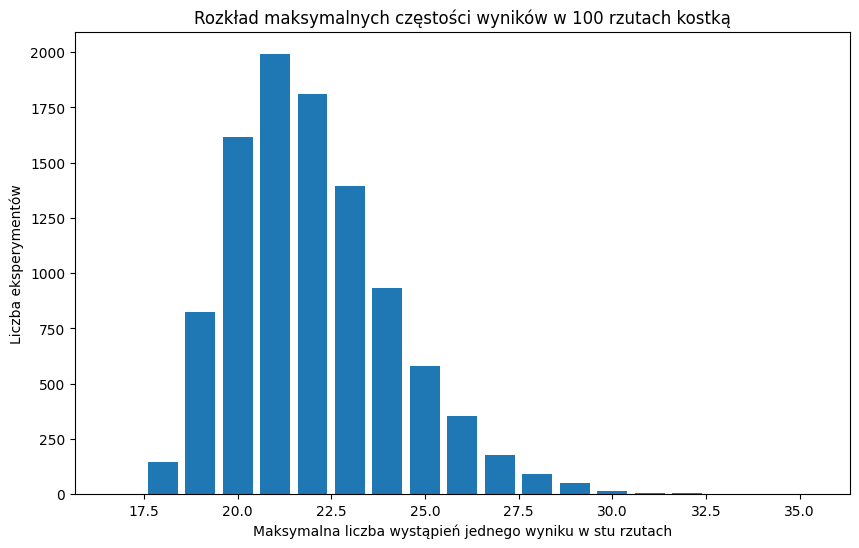

In [2]:
import numpy as np
import matplotlib.pyplot as plt



rng = np.random.default_rng(31415)


# Symulacja 1,000,000 rzutów kostką
wyniki = rng.integers(1, 7, 1000000)

# Przekształcenie wyników rzutów w macierz 10000 x 100 (10000 eksperymentów, 100 rzutów w każdym)
tabela_wynikow = wyniki.reshape(10000, 100)

# Obliczanie maksymalnej częstości wystąpienia dowolnego wyniku w każdym eksperymencie
# axis=1, arr=tabela_wynikow -> funkcja bedzie stosowana dla kazdego WIERSZA
# dla kazdego wiersza policz: np.bincount(x, minlength=7)[1:].max()
# np. x=[2,2,3,3,3] -> np.bincount(x, minlength=7)  [0,0,2,3,0,0,0]
maksymalne_czestosci = np.apply_along_axis(lambda x: np.bincount(x, minlength=7)[1:].max(), axis=1, arr=tabela_wynikow)

# Obliczanie prawdopodobieństwa uzyskania co najmniej 20 takich samych wyników w jednym eksperymencie
co_najmniej_20 = np.sum(maksymalne_czestosci >= 20) / 10000

print(f"Szansa na uzyskanie co najmniej 20 jednakowych wyników w 100 rzutach wynosi: {co_najmniej_20:.4f}")

# Tworzenie wykresu słupkowego dla rozkładu maksymalnych częstości
plt.figure(figsize=(10, 6))
plt.bar(*np.unique(maksymalne_czestosci, return_counts=True))
plt.xlabel('Maksymalna liczba wystąpień jednego wyniku w stu rzutach')
plt.ylabel('Liczba eksperymentów')
plt.title('Rozkład maksymalnych częstości wyników w 100 rzutach kostką')
plt.show()


In [3]:
 x=[2,2,3,3,3]

In [8]:
tmp=np.bincount(x, minlength=7)
print("tmp = ", tmp)
print("tmp[1:] = ", tmp[1:])
print("tmp[1:].max() = ", tmp[1:].max())

tmp =  [0 0 2 3 0 0 0]
tmp[1:] =  [0 2 3 0 0 0]
tmp[1:].max() =  3


# Ćwiczenie: wspólne urodziny

Jaka jest szansa, że w grupie n osób znajdą się dwie, które obchodzą urodziny tego samego dnia?
* Wyznacz wzór na prawdopodobieństwo i oblicz je (przy pomocy Pythona) dla wszystkich $n$ od 2 do 50.
* Sporządź wykres punktowy i odczytaj z niego najmniejszą wartość $n$, przy której to prawdopodobieństwo przekracza 1/2
* Wyznacz to samo prawdopodobieństwo drogą symulacji, dla $n$ od 20 do 30. Wyniki nanieś na ten sam wykres.


Dla uproszczenia zakładamy, że rok ma 365 dni i narodziny w każdym z nich są jednakowo prawdopodobne.

# Zadanie 1: warunkowa suma wyników
Rozważmy następujący eksperyment. Powtarzamy rzut dziesięcioma kostkami sześciennymi do pierwszego momentu, w którym na co najmniej siedmiu kostkach wypadną liczby nieparzyste. Jakie jest prawdopodobieństwo,
że w tym ostatnim rzucie uzyskamy więcej jedynek niż dwójek? Przeprowadź symulację na dwa sposoby:
* 1. z wykorzystaniem pętli `while`, z dokładnie określonym rozmiarem próby
* 2. bez użycia pętli i bez dokładnego określania rozmiaru próby.

Który sposób jest szybszy, a który z innych powodów (jakich?) lepszy? Czy można połączyć zalety obu
podejść?

# Zadanie 2: rozszerzenie zadania Z5 z listy 2 z ćwiczeń

Pewna firma zatrudnia $4n$ kobiet i $6n$ mężczyzn. Dla $k=0,1,\ldots,3n$ wyznacz przy pomocy symulacji prawdopodobieństwo, że w losowo wybranej grupie $3n$ pracowników znajdzie się $k$ kobiet i $3n-k$ mężczyzn. Przedstaw wyniki na wykresie. Przeprowadź symulacje dla $n = 2, 5, 10, 30.$ Jakiej zmiennej możesz użyć zamiast $k$ na osi $X$, aby na jednym wykresie umieścić wyniki dla wszystkich wartości $n$?

In [10]:
rng.choice(100,5, replace=True)

array([94, 12, 49, 51,  5])